# L02 : Simulate the Monty Hall Problem
Simulate three doors, one car, and two goats. \
Simulate three players: the switcher, the conservative, and the newcomer. \
Record who wins. \
Repeat it many times.

In [1]:
import numpy as np
import random
import time
import math
import matplotlib.pyplot as plt

In [2]:
def MontyHallProblem (simulations, N_doors, p): 

    if p >= N_doors - 1:
        raise ValueError(
            f"The presenter cannot open {p} doors if there are only {N_doors} of them. Maximum allowed: {N_doors-2}"
        )
    
    # initializations of win counters
    wins_conservative = 0
    wins_switcher = 0
    wins_newcomer = 0

    for i in range(simulations):
        car = random.randint(0, N_doors - 1) # random car position
        doors = np.zeros(N_doors)  # doors: 0=goat , 1=car
        doors[car] = 1

        initial_choice = random.randint(0, N_doors -1)
        possible_doors_to_open = []
        for j in range(N_doors):
            if j != initial_choice and doors[j] == 0:
                possible_doors_to_open.append(j)

        open_door = random.sample(possible_doors_to_open, p)

        remaining_doors = [j for j in range(N_doors) if j!= initial_choice and j not in open_door]

        conservative = initial_choice
        switcher = random.choice(remaining_doors)

        # first player: the conservative
        if doors[conservative] == 1:
            wins_conservative += 1

        # second player : the switcher
        if doors[switcher] == 1:
            wins_switcher += 1

        # third player : the newcomer
        all_closed_doors = [initial_choice] + remaining_doors
        newcomer = random.choice(all_closed_doors)
        if doors[newcomer] == 1:
            wins_newcomer +=1

    # Probabilities
    p_switcher = wins_switcher/N_sim
    p_conservative = wins_conservative/N_sim
    p_newcomer = wins_newcomer/N_sim

    return (p_switcher, p_conservative, p_newcomer)

In [3]:
N_sim = 100000
results = MontyHallProblem(simulations=100000, N_doors = 3, p=1)

print("Switcher winning probability: ", f"{results[0] * 100:0.2f}%")
print("Conservative winning probability: ", f"{results[1] * 100:0.2f}%")
print("Newcomer winning probability: ", f"{results[2] * 100:0.2f}%")

Switcher winning probability:  66.70%
Conservative winning probability:  33.30%
Newcomer winning probability:  49.70%


### Monty Hall generalization: the player has  N doors to choose from and the presenter opens  p < N of them. 
Study how the probability of winning changes as a function of  N and p.

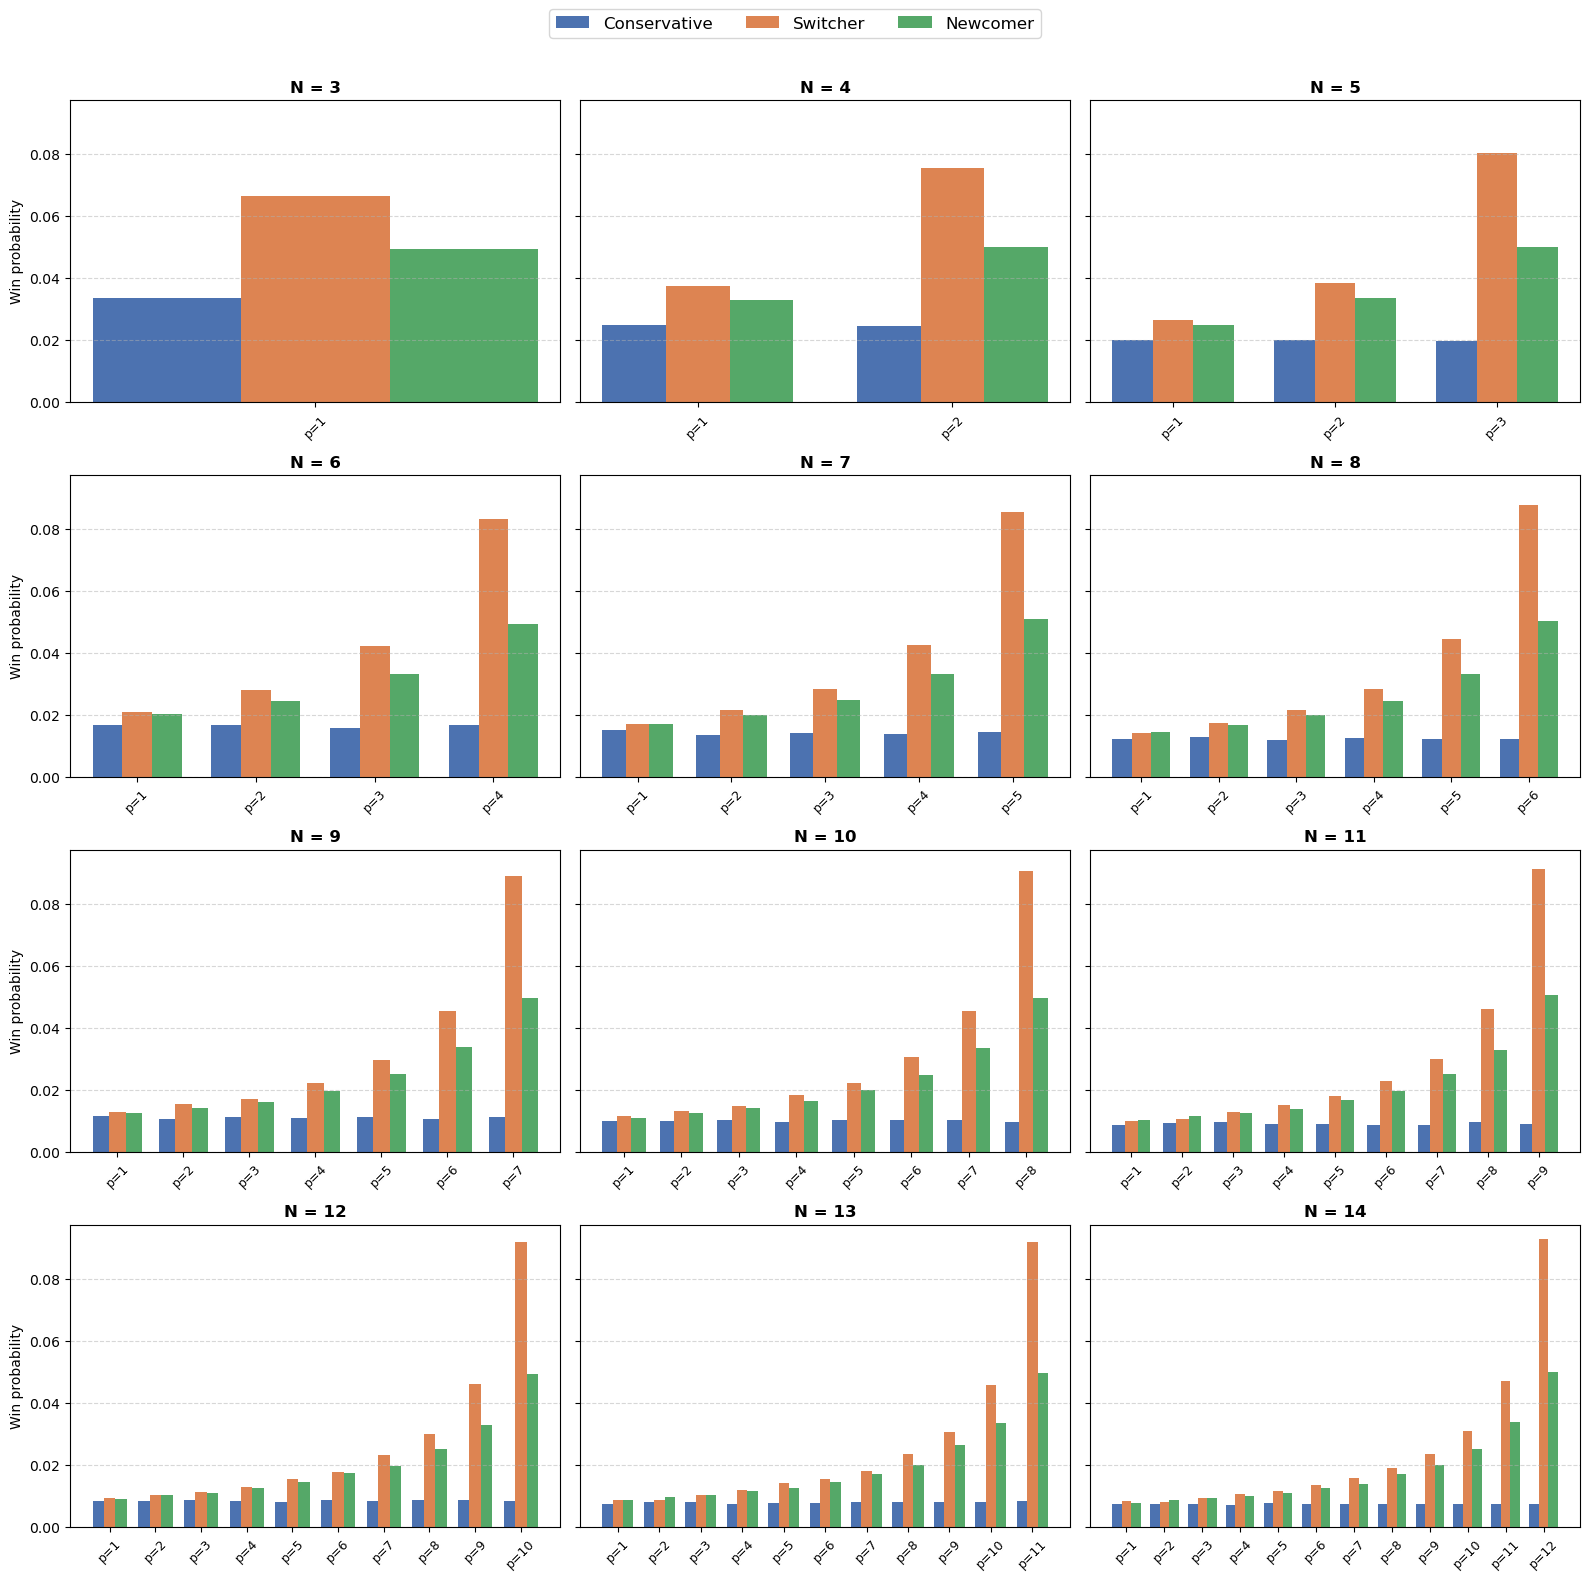

In [4]:
N_min = 3
N_max = 15
N_doors = list(range(N_min, N_max))

total_plots = len(N_doors)
ncols = 3
nrows = math.ceil(total_plots / ncols)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows), sharey=True
)
axes = axes.flatten()

for idx, N in enumerate(N_doors):
    ax = axes[idx]
    p_values = list(range(1, N - 1)) 
    
    prob_conservative = []
    prob_switcher = []
    prob_newcomer = []

    for p in p_values:
        switcher, conservative, newcomer = MontyHallProblem(simulations=10000, N_doors=N, p=p)
        prob_conservative.append(conservative)
        prob_switcher.append(switcher)
        prob_newcomer.append(newcomer)

    x = np.arange(len(p_values))  
    width = 0.25  

    ax.bar(
        x - width,
        prob_conservative,
        width,
        label="Conservative" if idx == 0 else "",
        color="#4C72B0",
    )
    ax.bar(
        x,
        prob_switcher,
        width,
        label="Switcher" if idx == 0 else "",
        color="#DD8452",
    )
    ax.bar(
        x + width,
        prob_newcomer,
        width,
        label="Newcomer" if idx == 0 else "",
        color="#55A868",
    )

    ax.set_title(f"N = {N}", fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"p={p}" for p in p_values], rotation=45, fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    if idx % ncols == 0:
        ax.set_ylabel("Win probability")
    
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

fig.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=3,
    fontsize=12,
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()